In [2]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
from rich import print as rprint
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}}  #关闭思考模式
)


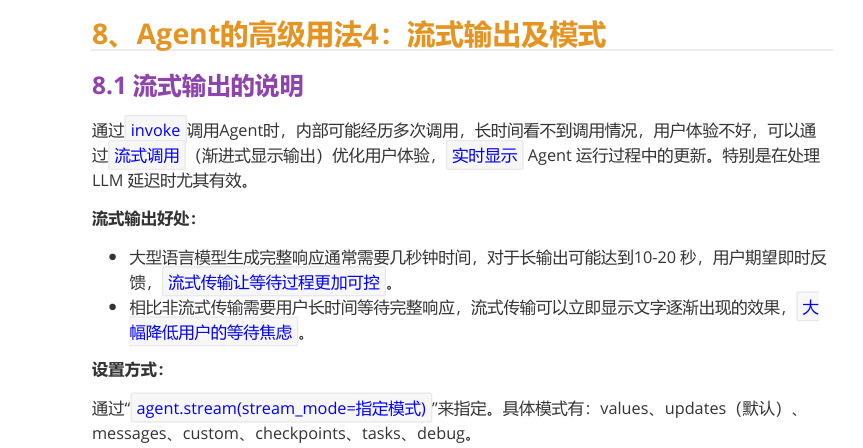

8.2 具体的输出模式
8.2.1 values输出模式
当stream_mode设置为values模式时，每个步骤执行后，都会输出完整的状态信息，适用于每一步都
要获取完整状态、状态持久化场景。
举例：

In [3]:
from langchain.agents import create_agent
from langchain.tools import tool
from typing import Dict, Any
from rich import print as rprint


@tool
def query_customer_data(customer_id: str) -> Dict[str, Any]:
    """
    查询客户基本信息

    Args:
        customer_id: 客户ID，用于唯一标识客户

    Returns:
        包含客户基本信息的字典，如姓名、等级、加入日期等
    """
    # 模拟数据库查询
    return {"name": "张三", "level": "VIP", "join_date": "2023-01-15"}


@tool
def check_order_history(customer_id: str) -> Dict[str, Any]:
    """
    查询客户订单历史
    Args:
    customer_id: 客户ID，用于唯一标识客户
    Returns:
    包含客户订单历史的字典，如总订单数、总花费等
    """
    return {"total_orders": 15, "total_spent": 25800.00}


@tool
def get_current_promotions() -> Dict[str, Any]:
    """
    获取当前可用促销活动
    Returns:
    包含当前可用促销活动的字典，如活动名称、有效日期等
    """
    return {
        "promotions": ["老用户优惠", "会员专属折扣"],
        "valid_until": "2027-01-31"
    }


# 创建客户服务Agent
customer_service_agent = create_agent(
    model=model,
    tools=[query_customer_data, check_order_history, get_current_promotions]
)
for chunk in customer_service_agent.stream(
        {"messages": [{"role": "user", "content": "查询客户ID为 CUST123456 的个人信息、历史订单和可用优惠"}]},
        stream_mode="values"
):
    rprint(chunk)
    print("-" * 50)

{
    'messages': [
        HumanMessage(
            content='查询客户ID为 CUST123456 的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='500e937e-a360-4d02-8208-c106efb9f56f'
        )
    ]
}

--------------------------------------------------


{
    'messages': [
        HumanMessage(
            content='查询客户ID为 CUST123456 的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='500e937e-a360-4d02-8208-c106efb9f56f'
        ),
        AIMessage(
            content='好的，我来查询客户ID为 CUST123456 
的相关信息。首先并行查询客户基本信息、历史订单和当前可用优惠。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 129,
                    'prompt_tokens': 453,
                    'total_tokens': 582,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 453
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'fc09e51e-d630-4eea-8ab4-27d9391738e7',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69d8-5c14-73a3-98cc-bcb0a13bb711-0',
            tool_calls=[
                {
                    'name': 'query_customer_data',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_00_1huAjRJ3PmSdvqB1MzDc2930',
                    'type': 'tool_call'
                },
                {
                    'name': 'check_order_history',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_01_i8WVl0NaKhaBboWElnOL0269',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_current_promotions',
                    'args': {},
                    'id': 'call_02_8MvMDpHEmsA989bu0xJ65183',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 453,
                'output_tokens': 129,
                'total_tokens': 582,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

--------------------------------------------------


{
    'messages': [
        HumanMessage(
            content='查询客户ID为 CUST123456 的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='500e937e-a360-4d02-8208-c106efb9f56f'
        ),
        AIMessage(
            content='好的，我来查询客户ID为 CUST123456 
的相关信息。首先并行查询客户基本信息、历史订单和当前可用优惠。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 129,
                    'prompt_tokens': 453,
                    'total_tokens': 582,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 453
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'fc09e51e-d630-4eea-8ab4-27d9391738e7',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69d8-5c14-73a3-98cc-bcb0a13bb711-0',
            tool_calls=[
                {
                    'name': 'query_customer_data',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_00_1huAjRJ3PmSdvqB1MzDc2930',
                    'type': 'tool_call'
                },
                {
                    'name': 'check_order_history',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_01_i8WVl0NaKhaBboWElnOL0269',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_current_promotions',
                    'args': {},
                    'id': 'call_02_8MvMDpHEmsA989bu0xJ65183',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 453,
                'output_tokens': 129,
                'total_tokens': 582,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
            name='query_customer_data',
            id='593c85ef-851a-4b62-9594-9bb21b615a4b',
            tool_call_id='call_00_1huAjRJ3PmSdvqB1MzDc2930'
        ),
        ToolMessage(
            content='{"total_orders": 15, "total_spent": 25800.0}',
            name='check_order_history',
            id='8727f699-9b80-4a68-8af2-b5d8801d8ddf',
            tool_call_id='call_01_i8WVl0NaKhaBboWElnOL0269'
        ),
        ToolMessage(
            content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
            name='get_current_promotions',
            id='87149367-bcc2-44ac-9a0e-736334137c02',
            tool_call_id='call_02_8MvMDpHEmsA989bu0xJ65183'
        )
    ]
}

--------------------------------------------------


{
    'messages': [
        HumanMessage(
            content='查询客户ID为 CUST123456 的个人信息、历史订单和可用优惠',
            additional_kwargs={},
            response_metadata={},
            id='500e937e-a360-4d02-8208-c106efb9f56f'
        ),
        AIMessage(
            content='好的，我来查询客户ID为 CUST123456 
的相关信息。首先并行查询客户基本信息、历史订单和当前可用优惠。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 129,
                    'prompt_tokens': 453,
                    'total_tokens': 582,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 453
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'fc09e51e-d630-4eea-8ab4-27d9391738e7',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f69d8-5c14-73a3-98cc-bcb0a13bb711-0',
            tool_calls=[
                {
                    'name': 'query_customer_data',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_00_1huAjRJ3PmSdvqB1MzDc2930',
                    'type': 'tool_call'
                },
                {
                    'name': 'check_order_history',
                    'args': {'customer_id': 'CUST123456'},
                    'id': 'call_01_i8WVl0NaKhaBboWElnOL0269',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_current_promotions',
                    'args': {},
                    'id': 'call_02_8MvMDpHEmsA989bu0xJ65183',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 453,
                'output_tokens': 129,
                'total_tokens': 582,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
            name='query_customer_data',
            id='593c85ef-851a-4b62-9594-9bb21b615a4b',
            tool_call_id='call_00_1huAjRJ3PmSdvqB1MzDc2930'
        ),
        ToolMessage(
            content='{"total_orders": 15, "total_spent": 25800.0}',
            name='check_order_history',
            id='8727f699-9b80-4a68-8af2-b5d8801d8ddf',
            tool_call_id='call_01_i8WVl0NaKhaBboWElnOL0269'
        ),
        ToolMessage(
            content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
            name='get_current_promotions',
            id='87149367-bcc2-44ac-9a0e-736334137c02',
            tool_call_id='call_02_8MvMDpHEmsA989bu0xJ65183'
        ),
        AIMessage(
            content='以下是客户 **CUST123456** 的详细信息汇总：\n\n---\n\n### 📋 客户基本信息\n| 项目 | 内容 
|\n|------|------|\n| **姓名** | 张三 |\n| **会员等级** | 🌟 **VIP** |\n| **加入日期** | 2023年1月15日 |\n\n### 🛒 
历史订单统计\n| 项目 | 数据 |\n|------|------|\n| **总订单数** | 15 笔 |\n| **累计消费金额** | ¥25,800.00 |\n\n### 
🎉 当前可用优惠活动\n| 优惠活动 | 有效期至 |\n|---------|---------|\n| 老用户优惠 | 2027年1月31日 |\n| 会员专属折扣
| 2027年1月31日 |\n\n---\n\n**总结：** 张三先生是 VIP 
会员，自2023年1月加入以来已累计下单15次，消费总额达25,800元。当前可享受 **老用户优惠** 和 **会员专属折扣** 
两项活动，有效期至2027年1月31日。如需进一步了解具体优惠细则，请随时告知！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 244,
                    'prompt_tokens': 678,
                    'total_tokens': 922,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_to

--------------------------------------------------


8.2.2 updates输出模式
这种模式就是默认模式。该模式中，每个步骤执行后，只增量更新状态中发生变化的内容，用于监控
Agent 执行进度，例如观察Agent决定调用工具、工具执行结果等步骤。
代码如下：

In [4]:
# 其他工具代码同上，保持不变
# ... ...
for chunk in customer_service_agent.stream(
        {"messages": [{"role": "user", "content": "查询客户ID为 CUST123456 的完整信息和可用优惠"}]},
        stream_mode="updates"
):
    rprint(chunk)
    print("-" * 50)

{
    'model': {
        'messages': [
            AIMessage(
                content='我来查询客户 CUST123456 的完整信息和当前可用促销活动。',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 117,
                        'prompt_tokens': 450,
                        'total_tokens': 567,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                        'prompt_cache_hit_tokens': 384,
                        'prompt_cache_miss_tokens': 66
                    },
                    'model_provider': 'deepseek',
                    'model_name': 'deepseek-v4-flash',
                    'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                    'id': '4b44d942-f137-4df8-97be-4e384b582a84',
                    'finish_reason': 'tool_calls',
                    'logprobs': None
                },
                id='lc_run--019f69f5-2586-7292-b799-4b4fa5f760cf-0',
                tool_calls=[
                    {
                        'name': 'query_customer_data',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_00_TKGl8N5ZfI5QWokW4fYd5874',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'check_order_history',
                        'args': {'customer_id': 'CUST123456'},
                        'id': 'call_01_hJrDzCfZ42GIVFKKCWuw1520',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'get_current_promotions',
                        'args': {},
                        'id': 'call_02_FzoWuCF0DwFgzaI5VWAX9943',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 450,
                    'output_tokens': 117,
                    'total_tokens': 567,
                    'input_token_details': {'cache_read': 384},
                    'output_token_details': {}
                }
            )
        ]
    }
}

--------------------------------------------------


{
    'tools': {
        'messages': [
            ToolMessage(
                content='{"total_orders": 15, "total_spent": 25800.0}',
                name='check_order_history',
                id='959deb30-f275-42b1-b874-a81b82c85230',
                tool_call_id='call_01_hJrDzCfZ42GIVFKKCWuw1520'
            )
        ]
    }
}

--------------------------------------------------


{
    'tools': {
        'messages': [
            ToolMessage(
                content='{"name": "张三", "level": "VIP", "join_date": "2023-01-15"}',
                name='query_customer_data',
                id='c53b4aa4-edbb-4e1a-a317-6a7f1bba987f',
                tool_call_id='call_00_TKGl8N5ZfI5QWokW4fYd5874'
            )
        ]
    }
}

--------------------------------------------------


{
    'tools': {
        'messages': [
            ToolMessage(
                content='{"promotions": ["老用户优惠", "会员专属折扣"], "valid_until": "2027-01-31"}',
                name='get_current_promotions',
                id='333e2642-6941-4ff3-8be4-987d2a689720',
                tool_call_id='call_02_FzoWuCF0DwFgzaI5VWAX9943'
            )
        ]
    }
}

--------------------------------------------------


{
    'model': {
        'messages': [
            AIMessage(
                content='以下是客户 **CUST123456** 的完整信息和可用优惠汇总：\n\n---\n\n### 👤 客户基本信息\n| 项目
| 内容 |\n|------|------|\n| **姓名** | 张三 |\n| **会员等级** | 🏆 VIP |\n| **加入日期** | 2023-01-15 |\n\n### 📊 
订单历史\n| 项目 | 数据 |\n|------|------|\n| **总订单数** | 15 笔 |\n| **累计消费金额** | ¥25,800.00 |\n\n### 🎉 
当前可用促销活动\n| 促销活动 | 有效期至 |\n|----------|----------|\n| ✅ **老用户优惠** | 2027-01-31 |\n| ✅ 
**会员专属折扣** | 2027-01-31 |\n\n---\n\n作为 **VIP 客户**，张三享有较高的消费水平（累计消费 
¥25,800），当前有两个促销活动可以参与，有效期均至 **2027年1月31日**，建议尽快使用。',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 215,
                        'prompt_tokens': 663,
                        'total_tokens': 878,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                        'prompt_cache_hit_tokens': 384,
                        'prompt_cache_miss_tokens': 279
                    },
                    'model_provider': 'deepseek',
                    'model_name': 'deepseek-v4-flash',
                    'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                    'id': '2662188d-b7eb-423c-b214-d70a9c0b467d',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--019f69f5-4400-7ed1-8899-3c8c39cdc7c7-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 663,
                    'output_tokens': 215,
                    'total_tokens': 878,
                    'input_token_details': {'cache_read': 384},
                    'output_token_details': {}
                }
            )
        ]
    }
}

--------------------------------------------------


8.2.3 messages输出模式
该模式中会输出流式返回的Token以及相关的元数据（如：来自哪个节点），可以用在实现类似
ChatGPT 的打字机效果场景，为聊天机器人等交互式应用提供最佳的实时体验。
代码如下：

In [5]:
# 其他工具代码同上，保持不变
# ... ...
for chunk in customer_service_agent.stream(
        {"messages": [{"role": "user", "content": "查询客户ID为 CUST123456 的完整信息和可用优惠"}]},
        stream_mode="messages"
):
    print(chunk)
    print("-" * 50)
# print(chunk[0].content,end="",flush=True)


(AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--019f69f6-cf38-7711-8346-5d1d0f2ab905', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:a4a48c1d-fcbd-eac4-541f-aa9209433ddc', 'checkpoint_ns': 'model:a4a48c1d-fcbd-eac4-541f-aa9209433ddc', 'ls_provider': 'deepseek', 'ls_model_name': 'deepseek-v4-flash', 'ls_model_type': 'chat', 'ls_temperature': None})
--------------------------------------------------
(AIMessageChunk(content='好的', additional_kwargs={}, response_metadata={'model_provider': 'deepseek'}, id='lc_run--019f69f6-cf38-7711-8346-5d1d0f2ab905', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model

8.2.4 tasks输出模式
该模式会输出当前task任务开始和结束的时间，包含任务的结果和错误信息，该模式用于监控任务的生
命周期。
代码如下：

In [6]:
# 其他工具代码同上，保持不变
# ... ...
for chunk in customer_service_agent.stream(
        {"messages": [{"role": "user", "content": "查询客户ID为 CUST123456 的完整信息和可用优惠"}]},
        stream_mode="tasks"
):
    print(chunk)
    print("-" * 50)

{'id': '9253e391-1ce1-0c73-c359-84a4028ac2ed', 'name': 'model', 'input': {'messages': [HumanMessage(content='查询客户ID为 CUST123456 的完整信息和可用优惠', additional_kwargs={}, response_metadata={}, id='583e2f97-1a51-4486-9952-773dddb9e082')]}, 'triggers': ('branch:to:model',)}
--------------------------------------------------
{'id': '9253e391-1ce1-0c73-c359-84a4028ac2ed', 'name': 'model', 'error': None, 'result': {'messages': [AIMessage(content='好的，我来查询客户ID为 CUST123456 的完整信息和当前可用的促销活动。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 122, 'prompt_tokens': 450, 'total_tokens': 572, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384}, 'prompt_cache_hit_tokens': 384, 'prompt_cache_miss_tokens': 66}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '95293028-6f0f-4ebe-840c-7ff09b1b5d4e', 'finish_reason': 'tool_call

debug输出模式
该模式与tasks模式类似，比task模式多输出任务步骤、时间戳、task类型（task/task_result），该模式
用于调试、监控task任务的生命周期。
代码如下：


In [7]:
# 其他工具代码同上，保持不变
# ... ...
for chunk in customer_service_agent.stream(
        {"messages": [{"role": "user", "content": "查询客户ID为 CUST123456 的完整信息和可用优惠"}]},
        stream_mode="debug"
):
    print(chunk)
    print("-" * 50)

{'step': 1, 'timestamp': '2026-07-16T08:09:30.155323+00:00', 'type': 'task', 'payload': {'id': 'a154bc85-b5d0-9eb7-04cf-ac59f48d92e9', 'name': 'model', 'input': {'messages': [HumanMessage(content='查询客户ID为 CUST123456 的完整信息和可用优惠', additional_kwargs={}, response_metadata={}, id='1413605f-0ffc-4a03-b266-91e9a05bd6f3')]}, 'triggers': ('branch:to:model',)}}
--------------------------------------------------
{'step': 1, 'timestamp': '2026-07-16T08:09:31.662334+00:00', 'type': 'task_result', 'payload': {'id': 'a154bc85-b5d0-9eb7-04cf-ac59f48d92e9', 'name': 'model', 'error': None, 'result': {'messages': [AIMessage(content='好的，我来查询客户ID为 CUST123456 的完整信息以及当前可用优惠。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 450, 'total_tokens': 571, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384}, 'prompt_cache_hit_tokens': 384, 'prompt_cache_miss_tokens': 66}, 'model_provider': 'deepse

checkpoints输出模式
该模式中，每当检查点（checkpoint）被创建时会触发输出，输出包含检查点中的状态，用于需要状态
持久化、工作流恢复或分布式执行跟踪的高级场景。
代码案例如下：

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

# 其他工具代码同上，保持不变
# ... ...
# 1. 创建内存检查点存储
checkpointer = InMemorySaver()
# 2. 创建Agent
customer_service_agent = create_agent(
    model=model,
    tools=[query_customer_data, check_order_history,
           get_current_promotions],
    checkpointer=checkpointer  # 启用检查点
)
# 3. 创建唯一的会话ID
config = {"configurable": {"thread_id": "session01"}}
# 4. 调用Agent
checkpoint_count = 0
# 使用checkpoints模式进行流式监控
for chunk in customer_service_agent.stream(
        {"messages": [{"role": "user", "content": "查询客户ID为 CUST123456 的完整信息和可用优惠"}]}, config=config,
        stream_mode="checkpoints"
):
    checkpoint_count += 1
    print(f"检查点 #{checkpoint_count}")
    print(chunk)
    print("-" * 50)

custom输出模式
开发者通过get_stream_writer在工具或节点内部自定义发送的数据，用于输出业务逻辑相关的进
度信息（如“已处理10/100条记录”）、自定义日志或指标。
举例：生成销售报告和库存报告Agent

In [8]:
from langchain.agents import create_agent
from langgraph.config import get_stream_writer
from langchain.tools import tool
import time


@tool
def generate_sales_report() -> str:
    """生成销售报告"""
    writer = get_stream_writer()
    writer({"type": "生成销售报告", "message": "开始生成销售报告"})
    # 模拟数据处理
    for i in range(1, 4):
        time.sleep(0.5)
        writer({"type": "生成销售报告", "message": f"生成销售报告进度百分比：{i *
                                                                             25}%"})
    writer({"type": "生成销售报告", "message": "报告生成完成"})
    return f"销售报告：总收入150万元，同比增长12%"


@tool
def generate_inventory_report() -> str:
    """生成库存报告"""
    writer = get_stream_writer()
    writer("开始库存分析...")
    time.sleep(0.5)
    writer("检查当前库存量...")
    time.sleep(0.5)
    writer("生成库存报告...")
    return "当前库存量为10000件，库存充足，无异常"


# 创建报告生成agent
reporting_agent = create_agent(
    model=model,
    tools=[generate_sales_report, generate_inventory_report]
)
for chunk in reporting_agent.stream(
        {"messages": [{"role": "user", "content": "生成销售报告和库存报告"}]},
        stream_mode="custom"
):
    print(chunk)
print("-" * 50)

开始库存分析...
{'type': '生成销售报告', 'message': '开始生成销售报告'}
检查当前库存量...
{'type': '生成销售报告', 'message': '生成销售报告进度百分比：25%'}
生成库存报告...
{'type': '生成销售报告', 'message': '生成销售报告进度百分比：50%'}
{'type': '生成销售报告', 'message': '生成销售报告进度百分比：75%'}
{'type': '生成销售报告', 'message': '报告生成完成'}
--------------------------------------------------


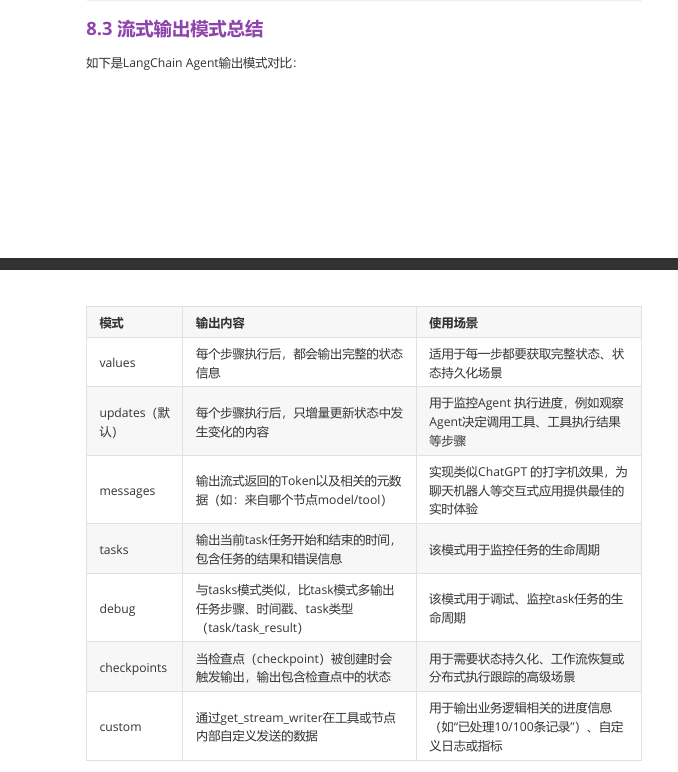
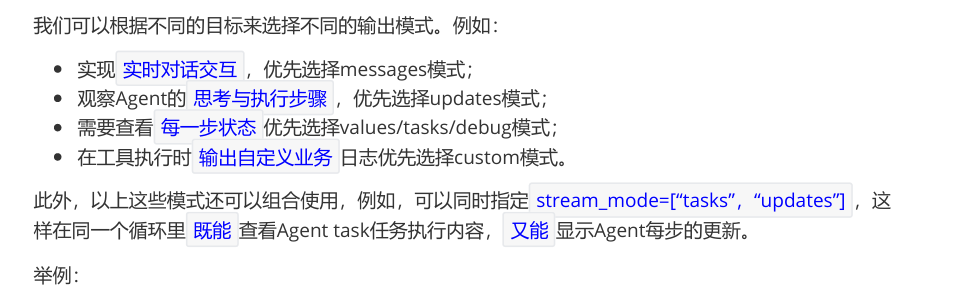

In [9]:
# 其他工具代码同上，保持不变
# ... ...
# 创建客户服务Agent
customer_service_agent = create_agent(
    model=model,
    tools=[query_customer_data, check_order_history, get_current_promotions]
)
for stream_mode, chunk in customer_service_agent.stream(
        {"messages": [{"role": "user", "content": "查询客户ID为 CUST123456 的完整信息和可用优惠"}]},
        stream_mode=["tasks", "updates"]
):
    print(f"当前流模式: {stream_mode}, 当前数据: {chunk}")
    print("-" * 50)

当前流模式: tasks, 当前数据: {'id': 'be604cae-bbfe-7d3f-177d-fc608234292a', 'name': 'model', 'input': {'messages': [HumanMessage(content='查询客户ID为 CUST123456 的完整信息和可用优惠', additional_kwargs={}, response_metadata={}, id='3f62f072-321a-4286-a30d-df0bcd2862a9')]}, 'triggers': ('branch:to:model',)}
--------------------------------------------------
当前流模式: updates, 当前数据: {'model': {'messages': [AIMessage(content='我来查询客户 CUST123456 的完整信息和当前可用的促销活动。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 450, 'total_tokens': 568, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384}, 'prompt_cache_hit_tokens': 384, 'prompt_cache_miss_tokens': 66}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'b5efbde9-afef-4a7e-b4b2-502e130f822d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f69fc

当指定多模式后，可以通过“
for stream_mode, chunk in customer_service_agent.stream... ”来遍历
dict，dict的key(stream_mode)是执行模式，value(chunk)是该模式输出的结果。代码运行输出结果如
下：